To begin copy this notebook to your own drive:

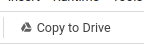


### Submission Instructions:
1. **Download the notebook** (in the menubar, select File$\rightarrow$Download .ipynb)
2. **Upload the downloaded notebook (.ipynb file) to your repository**.


Make sure you fill in any place that says `YOUR CODE HERE`, and all the cells include their outputs

Note: To use a GPU, do the following: Runtime$\rightarrow$Change runtime type$\rightarrow$ GPU

In [1]:
!pip install datasets
!pip install transformers
!pip install nltk
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00


In [2]:
import nltk
nltk.download('punkt_tab')
## If you're usig older version of nltk, you night need to use this lin instead:
# nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
# The assignment zip includes 2 files you need to use:
# 'glove.npy' and 'vocab.json'.
# you can upload the directly to this session storage, using the "files" button on the left menu,
# and then the "upload" button on the top of the sidebar. This upload is only valid for each session,
# so if you restart the session you'll neeed to upload the files again

# If you prefer, You can download the files directly to the sessio using these three lines:
import gdown
gdown.download('https://drive.google.com/uc?export=download&id=1PFOG06NEsTL6VieKQjMk1oNzyzcUtiWn', 'glove.npy', quiet=False)
gdown.download('https://drive.google.com/uc?export=download&id=1-3SxpirQjmX-RCRyRjKdP2L7G_tNgp00', 'vocab.json', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1PFOG06NEsTL6VieKQjMk1oNzyzcUtiWn
From (redirected): https://drive.google.com/uc?export=download&id=1PFOG06NEsTL6VieKQjMk1oNzyzcUtiWn&confirm=t&uuid=5f66ec74-756e-4965-ba23-ae044344c8f3
To: /content/glove.npy
100%|██████████| 480M/480M [00:07<00:00, 63.6MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1-3SxpirQjmX-RCRyRjKdP2L7G_tNgp00
To: /content/vocab.json
100%|██████████| 7.69M/7.69M [00:00<00:00, 27.0MB/s]


'vocab.json'

In [4]:
import numpy as np
from datasets import load_dataset

raw_datasets = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [5]:
from nltk.tokenize import word_tokenize
import json

with open("vocab.json") as f:
  vocab = json.load(f)

def tokenize_function(example):
  sentences = [x.lower() for x in example['text']]
  tokenized_sentences = [word_tokenize(x) for x in sentences]
  tokenized_idx = [[vocab[word] if word in vocab else vocab["unk"] for word in x] for x in tokenized_sentences]
  max_size = max([len(x) for x in tokenized_idx])
  final_tokenized_idx = tokenized_idx

  return {"labels":example['label'],'input_ids':final_tokenized_idx}

In [6]:
small_train_dataset = raw_datasets['train'].shuffle(seed=42).map(tokenize_function,batched=True)
small_eval_dataset = raw_datasets['test'].shuffle(seed=42).map(tokenize_function,batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [7]:
def pad_sequence_to_length(
    sequence,
    desired_length: int,
    default_value = lambda: 0,
    padding_on_right: bool = True,
):
    sequence = list(sequence)
    # Truncates the sequence to the desired length.
    if padding_on_right:
        padded_sequence = sequence[:desired_length]
    else:
        padded_sequence = sequence[-desired_length:]
    # Continues to pad with default_value() until we reach the desired length.
    pad_length = desired_length - len(padded_sequence)
    # This just creates the default value once, so if it's a list, and if it gets mutated
    # later, it could cause subtle bugs. But the risk there is low, and this is much faster.
    values_to_pad = [default_value()] * pad_length
    if padding_on_right:
        padded_sequence = padded_sequence + values_to_pad
    else:
        padded_sequence = values_to_pad + padded_sequence
    return padded_sequence

In [8]:
from evaluate import load
metric = load("accuracy")

### If you're using older versions, use:
# metric = dataset.load_metric("accuracy")

def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [9]:
from dataclasses import dataclass

@dataclass
class DataCollatorWithPadding:

  def __call__(self, features):
    features_dict={}
    if "labels" in features[0]:

      features_dict["labels"] = torch.tensor([x.pop("labels") for x in features]).long()

    input_ids = [x.pop("input_ids") for x in features]
    max_len = max(len(x) for x in input_ids)
    masks = [[1]*len(x) for x in input_ids]

    features_dict["input_ids"] = torch.tensor([pad_sequence_to_length(x,max_len) for x in input_ids]).long()
    features_dict["attention_masks"] = torch.tensor([pad_sequence_to_length(x,max_len) for x in masks]).long()

    return features_dict


## SECTION A - DAN implentation

In [10]:
from torch import nn
import torch
#Use nn.Sequential and nn.Linear for the network, and nn.CrossEntropyLoss for the loss.
#Make sure that the final layer has output dimension of size 2.
class DAN(nn.Module):
    def __init__(self, embed_dim=300, hidden_dim=300, num_hidden_layers=2, word_dropout=0.0, activation_fn=nn.ReLU):
        super().__init__()
        self.num_labels = 2
        self.embeddings = nn.Embedding.from_pretrained(torch.FloatTensor(np.load("glove.npy")))
        self.dropout = nn.Dropout(p=word_dropout)

        # YOUR CODE HERE
        self.word_dropout = word_dropout

        layers = []
        input_size = embed_dim
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(input_size, hidden_dim))
            layers.append(activation_fn())
            input_size = hidden_dim

        layers.append(nn.Linear(input_size, self.num_labels))

        self.classifier = nn.Sequential(*layers)
        self.loss = nn.CrossEntropyLoss()


    def forward(self,input_ids,attention_masks,labels=None,**kwargs):
      # YOUR CODE HERE
      embs = self.embeddings(input_ids)
      embs = self.dropout(embs)
      mask_expanded = attention_masks.unsqueeze(-1).float()
      sum_embs = torch.sum(embs * mask_expanded, dim=1)
      valid_lengths = attention_masks.sum(dim=1, keepdim=True).float().clamp(min=1e-9)
      avg = sum_embs / valid_lengths
      # END YOUR END

      res = self.classifier(avg)
      loss = self.loss(res,labels)
      return {"loss":loss,"logits":res}


In [11]:
#Hint: You may want to look at https://huggingface.co/transformers/main_classes/callback.html
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

co = DataCollatorWithPadding()
training_args = TrainingArguments("DAN",
                                  # YOUR CODE HERE
                                  num_train_epochs=15 , #must be at least 10.
                                  per_device_train_batch_size=64,
                                  per_device_eval_batch_size=64,
                                  learning_rate=1e-3,
                                  load_best_model_at_end=True,
                                  save_strategy="epoch",
                                  # END YOUR END

                                  save_total_limit=2,
                                  log_level="error",
                                  eval_strategy="epoch") # Older version might need 'evaluation_strateg' instead
model = DAN()



trainer = Trainer(
    model=model,
    data_collator=co,
    args=training_args,
    callbacks = [
                 # YOUR CODE HERE
                 EarlyStoppingCallback(early_stopping_patience=3)
                 # END YOUR END
    ],
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics,
)


In [12]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.407304,0.816600
2,0.453583,0.417667,0.807960
3,0.394639,0.385543,0.828280
4,0.388984,0.387243,0.828040
5,0.388984,0.404502,0.817000
6,0.375023,0.378787,0.832880
7,0.374947,0.382541,0.830920
8,0.373782,0.387868,0.830040
9,0.366098,0.371920,0.838000
10,0.366098,0.370119,0.836600


TrainOutput(global_step=5865, training_loss=0.3740634264543538, metrics={'train_runtime': 501.656, 'train_samples_per_second': 747.524, 'train_steps_per_second': 11.691, 'total_flos': 0.0, 'train_loss': 0.3740634264543538, 'epoch': 15.0})

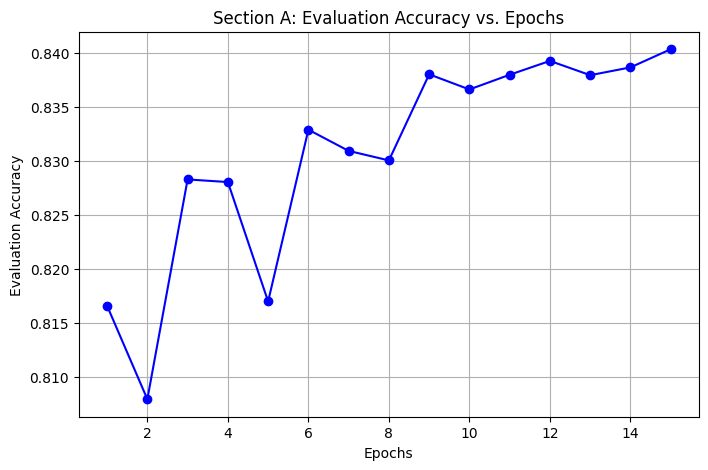

In [13]:
import matplotlib.pyplot as plt

eval_accs = [log['eval_accuracy'] for log in trainer.state.log_history if 'eval_accuracy' in log]
epochs = range(1, len(eval_accs) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, eval_accs, marker='o', linestyle='-', color='b')
plt.title('Section A: Evaluation Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Evaluation Accuracy')
plt.grid(True)
plt.show()

## SECTION B - Trying drpout

--- Training with word dropout: 0.0 ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.409147,0.816320
2,0.457681,0.385144,0.830920
3,0.394793,0.387259,0.827040
4,0.387348,0.379274,0.832160
5,0.387348,0.393104,0.823960
6,0.377398,0.378098,0.832120
7,0.376037,0.388133,0.828720
8,0.374742,0.387864,0.828400
9,0.367241,0.371429,0.838800
10,0.367241,0.370691,0.836680


Best accuracy for dropout 0.0: 0.8398

--- Training with word dropout: 0.1 ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.404966,0.816840
2,0.453025,0.386561,0.830480
3,0.400153,0.417736,0.808360
4,0.401037,0.388973,0.826800
5,0.401037,0.381318,0.830720
6,0.383243,0.380149,0.832640
7,0.386007,0.381308,0.830120
8,0.383442,0.384566,0.829840
9,0.377149,0.371726,0.837080
10,0.377149,0.373511,0.836080


Best accuracy for dropout 0.1: 0.8402

--- Training with word dropout: 0.2 ---


...

Best accuracy for dropout 0.3: 0.8395

--- Training with word dropout: 0.4 ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.416609,0.812560
2,0.476143,0.395610,0.826520
3,0.428886,0.388468,0.829200
4,0.424594,0.394192,0.822080
5,0.424594,0.404225,0.814600
6,0.415152,0.383597,0.830200
7,0.413640,0.416555,0.809400
8,0.413977,0.381683,0.829320
9,0.407133,0.375027,0.834280
10,0.407133,0.378175,0.836240


Best accuracy for dropout 0.4: 0.8371

--- Training with word dropout: 0.5 ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.411505,0.814040
2,0.482427,0.402488,0.824600
3,0.442724,0.394636,0.827000
4,0.437304,0.404104,0.817440
5,0.437304,0.426946,0.798760
6,0.427364,0.387590,0.828360
7,0.426591,0.403785,0.814840
8,0.423860,0.388425,0.825520
9,0.419908,0.379128,0.831400
10,0.419908,0.382327,0.834800


Best accuracy for dropout 0.5: 0.8363



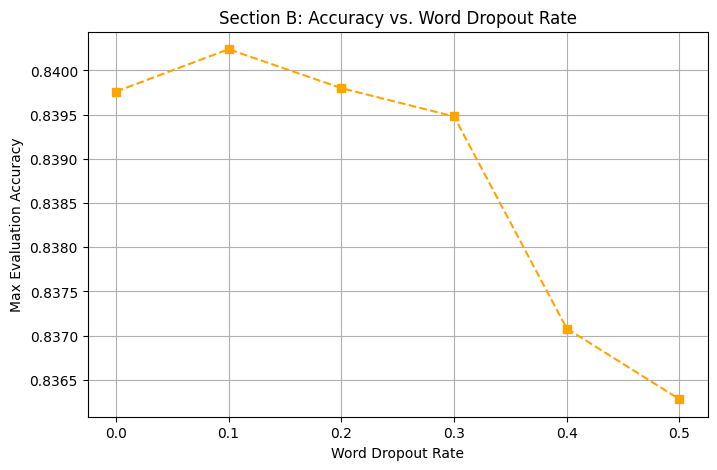

In [14]:
# YOUR CODE HERE
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
best_accuracies = []

for drop_rate in dropout_rates:
    print(f"--- Training with word dropout: {drop_rate} ---")

    model_b = DAN(word_dropout=drop_rate)

    trainer_b = Trainer(
        model=model_b,
        data_collator=co,
        args=training_args,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        train_dataset=small_train_dataset,
        eval_dataset=small_eval_dataset,
        compute_metrics=compute_metrics,
    )

    trainer_b.train()

    eval_accs = [log['eval_accuracy'] for log in trainer_b.state.log_history if 'eval_accuracy' in log]
    best_acc = max(eval_accs)
    best_accuracies.append(best_acc)
    print(f"Best accuracy for dropout {drop_rate}: {best_acc:.4f}\n")

# Plotting the results as requested by Section B
plt.figure(figsize=(8, 5))
plt.plot(dropout_rates, best_accuracies, marker='s', color='orange', linestyle='--')
plt.title('Section B: Accuracy vs. Word Dropout Rate')
plt.xlabel('Word Dropout Rate')
plt.ylabel('Max Evaluation Accuracy')
plt.grid(True)
plt.show()

## SCETION C - Different Layer num

--- Training DAN with 0 hidden layers ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.610090,0.699200
2,0.632087,0.569088,0.739800
3,0.568105,0.542244,0.760400
4,0.536360,0.523771,0.771840
5,0.536360,0.509354,0.781360
6,0.511511,0.498329,0.786000
7,0.497183,0.490210,0.789400
8,0.485673,0.483535,0.792520
9,0.478905,0.478478,0.794920
10,0.478905,0.474462,0.796320


--- Training DAN with 1 hidden layers ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.424421,0.808320
2,0.480712,0.399709,0.820680
3,0.397022,0.386987,0.828480
4,0.383808,0.384013,0.828920
5,0.383808,0.388848,0.824800
6,0.374053,0.381730,0.830360
7,0.373306,0.383915,0.829240
8,0.371105,0.374792,0.834720
9,0.368289,0.373958,0.835360
10,0.368289,0.371729,0.835320


--- Training DAN with 2 hidden layers ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.409147,0.816320
2,0.457681,0.385144,0.830920
3,0.394793,0.387259,0.827040
4,0.387348,0.379274,0.832160
5,0.387348,0.393104,0.823960
6,0.377398,0.378098,0.832120
7,0.376037,0.388133,0.828720
8,0.374742,0.387864,0.828400
9,0.367241,0.371429,0.838800
10,0.367241,0.370691,0.836680


--- Training DAN with 3 hidden layers ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.389366,0.828160
2,0.450144,0.396567,0.823800
3,0.392915,0.390898,0.825960
4,0.397094,0.384085,0.829760
5,0.397094,0.377769,0.835120
6,0.381064,0.383052,0.831120
7,0.381562,0.389042,0.828240
8,0.373712,0.381818,0.833160


--- Training DAN with 4 hidden layers ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.415755,0.818400
2,0.460788,0.425359,0.802040
3,0.406166,0.427588,0.796880
4,0.394229,0.387943,0.831400
5,0.394229,0.404377,0.816240
6,0.384131,0.379434,0.835240
7,0.378054,0.389661,0.827680
8,0.379022,0.384930,0.832600
9,0.367269,0.375557,0.837560
10,0.367269,0.376243,0.833680


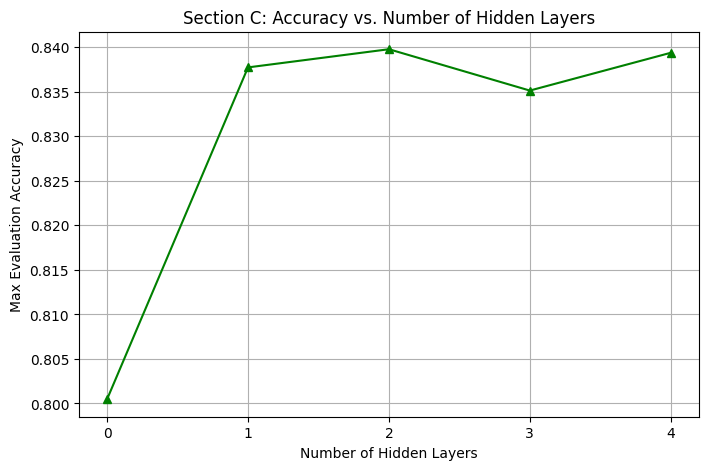

In [15]:
# YOUR CODE HERE


num_layers_list = [0, 1, 2, 3, 4]
layer_accuracies = []

for num_layers in num_layers_list:
    print(f"--- Training DAN with {num_layers} hidden layers ---")



    model_c = DAN(num_hidden_layers=num_layers, word_dropout=0.0)

    trainer_c = Trainer(
        model=model_c,
        data_collator=co,
        args=training_args,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        train_dataset=small_train_dataset,
        eval_dataset=small_eval_dataset,
        compute_metrics=compute_metrics,
    )

    trainer_c.train()


    eval_accs = [log['eval_accuracy'] for log in trainer_c.state.log_history if 'eval_accuracy' in log]
    best_acc = max(eval_accs)
    layer_accuracies.append(best_acc)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(num_layers_list, layer_accuracies, marker='^', color='green', linestyle='-')
plt.title('Section C: Accuracy vs. Number of Hidden Layers')
plt.xlabel('Number of Hidden Layers')
plt.ylabel('Max Evaluation Accuracy')
plt.xticks(num_layers_list)
plt.grid(True)
plt.show()

## SECTION D - Activations

--- Training with ReLU activation ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.409147,0.816320
2,0.457681,0.385144,0.830920
3,0.394793,0.387259,0.827040
4,0.387348,0.379274,0.832160
5,0.387348,0.393104,0.823960
6,0.377398,0.378098,0.832120
7,0.376037,0.388133,0.828720
8,0.374742,0.387864,0.828400
9,0.367241,0.371429,0.838800
10,0.367241,0.370691,0.836680


--- Training with Tanh activation ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.655530,0.689120
2,0.447969,0.441134,0.793760
3,0.404377,0.395679,0.824600
4,0.391744,0.449480,0.792120
5,0.391744,0.396665,0.823000
6,0.381559,0.385737,0.830280
7,0.384164,0.387041,0.830280
8,0.385249,0.385045,0.830240
9,0.376798,0.379900,0.835520
10,0.376798,0.377489,0.834040


--- Training with GELU activation ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.402393,0.820120
2,0.450119,0.387782,0.829800
3,0.397614,0.384074,0.830840
4,0.388839,0.389177,0.827480
5,0.388839,0.408663,0.816160
6,0.379838,0.386844,0.830120


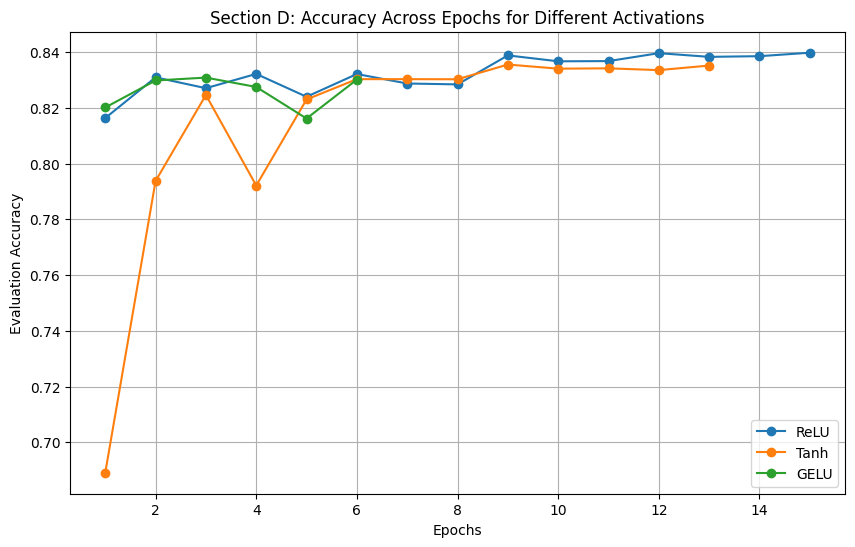

In [16]:
# YOUR CODE HERE

import torch.nn as nn
import matplotlib.pyplot as plt

# Dictionary of the 3 activation functions to test
activations = {
    "ReLU": nn.ReLU,
    "Tanh": nn.Tanh,
    "GELU": nn.GELU
}

activation_histories = {}

for act_name, act_fn in activations.items():
    print(f"--- Training with {act_name} activation ---")
    model_d = DAN(activation_fn=act_fn)

    trainer_d = Trainer(
        model=model_d,
        data_collator=co,
        args=training_args,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        train_dataset=small_train_dataset,
        eval_dataset=small_eval_dataset,
        compute_metrics=compute_metrics,
    )

    trainer_d.train()

    # Extract epoch-by-epoch accuracy
    eval_accs = [log['eval_accuracy'] for log in trainer_d.state.log_history if 'eval_accuracy' in log]
    activation_histories[act_name] = eval_accs

# Plotting all three lines on the same graph
plt.figure(figsize=(10, 6))
for act_name, acc_history in activation_histories.items():
    epochs = range(1, len(acc_history) + 1)
    plt.plot(epochs, acc_history, marker='o', label=act_name)

plt.title('Section D: Accuracy Across Epochs for Different Activations')
plt.xlabel('Epochs')
plt.ylabel('Evaluation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## SECRION E - Sample 5 examples

In [17]:
# YOUR CODE HERE
import numpy as np

# Note: Change 'trainer_d' below if your best model was from a different section
# (e.g., 'trainer' from Section A, or 'trainer_b' from Section B).
best_trainer = trainer_d

# 1. Get predictions on the evaluation dataset
predictions_output = best_trainer.predict(small_eval_dataset)
predictions = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

# 2. Find indices where the model's prediction didn't match the true label
incorrect_indices = np.where(predictions != true_labels)[0]

# 3. Create a reverse vocabulary dictionary to turn token IDs back into words
reverse_vocab = {v: k for k, v in vocab.items()}

# 4. Print out 5 sample errors
print(f"Total incorrect predictions: {len(incorrect_indices)}")
print("--- 5 Sampled Errors ---\n")

for i in range(5):
    idx = incorrect_indices[i]
    pred_label = "Positive" if predictions[idx] == 1 else "Negative"
    true_label = "Positive" if true_labels[idx] == 1 else "Negative"

    # Extract the original un-padded token IDs directly from the dataset
    token_ids = small_eval_dataset[int(idx)]['input_ids']

    # Decode back to text
    decoded_words = [reverse_vocab.get(t, "<UNK>") for t in token_ids]
    text = " ".join(decoded_words)

    print(f"Example {i+1}:")
    print(f"Predicted: {pred_label} | Actual: {true_label}")
    # Printing the first 800 characters so it doesn't flood your screen
    print(f"Text: {text[:800]}...\n")
    print("-" * 50)

Total incorrect predictions: 4229
--- 5 Sampled Errors ---

Example 1:
Predicted: Negative | Actual: Positive
Text: this is the latest entry in the long series of films with the french agent , unk . 117 ( the french answer to james bond ) . the series was launched in the early 1950 's , and spawned at least eight films ( none of which was ever released in the u.s. ) . ' unk : cairo , nest of spies ' is a breezy little comedy that should not ... repeat not , be taken too seriously . our protagonist finds himself in the middle of a spy chase in egypt ( with morroco doing stand in for egypt ) to find out about a long lost friend . what follows is the standard james unk unk kind of antics . although our man is something of an overt xenophobe , sexist , homophobe , it 's treated as pure farce ( as i said , do n't take it too seriously ) . although there is a bit of rough language & cartoon violence , it 's b...

--------------------------------------------------
Example 2:
Predicted: Negati